<a href="https://colab.research.google.com/github/Iffraah96/ShopSense-AI/blob/main/notebook/02_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍️ ShopSense AI

# Notebook 2: Exploratory Data Analysis (EDA)

## Project Objective

The goal of this notebook is to explore the cleaned customer review dataset and uncover meaningful business insights through data visualization.

By the end of this notebook, we get to know about:

- Customer rating patterns
- Product recommendation trends
- Customer demographics
- Department performance
- Review characteristics
- Relationships between important variables

These insights will help businesses make data-driven decisions and prepare the data for machine learning.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set a clean plotting style
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")

## Load Clean Dataset

In [2]:
df = pd.read_csv('clean_women_clothing_review_dataset.csv')
df.head()


,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name
0,767,33,No Title,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,No Title,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
df.shape

(22641, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22641 entries, 0 to 22640
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   clothing_id              22641 non-null  int64 
 1   age                      22641 non-null  int64 
 2   title                    22641 non-null  object
 3   review_text              22641 non-null  object
 4   rating                   22641 non-null  int64 
 5   recommended_ind          22641 non-null  int64 
 6   positive_feedback_count  22641 non-null  int64 
 7   division_name            22641 non-null  object
 8   department_name          22641 non-null  object
 9   class_name               22641 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.7+ MB


In [5]:
df.isnull().sum()

,0
clothing_id,0
age,0
title,0
review_text,0
rating,0
recommended_ind,0
positive_feedback_count,0
division_name,0
department_name,0
class_name,0


## Analysis 1 - Rating Distribution

Customer ratings are one of the most important indicators of customer satisfaction.

This section will visualize how ratings are distributed from 1 to 5 stars.

This helps to understand whether customers generally have positive or negative shopping experiences.

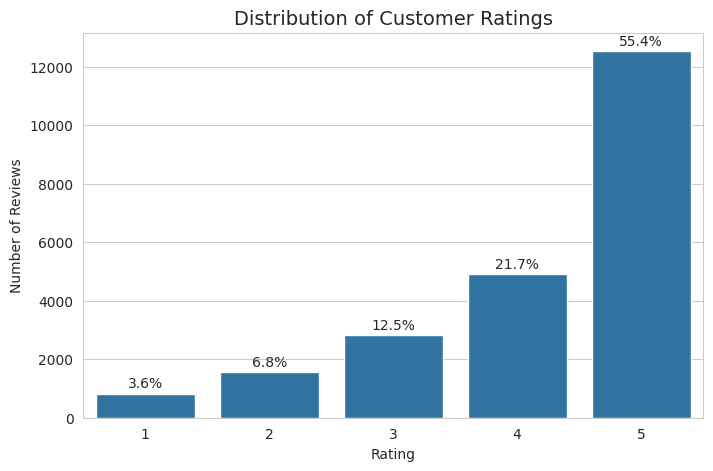

In [6]:
# Rating Distribution with Percentages

# Count reviews for each rating
rating_counts = df["rating"].value_counts().sort_index()

# Calculate percentages
rating_percentages = (rating_counts / rating_counts.sum()) * 100

# Create the chart
plt.figure(figsize=(8, 5))

ax = sns.barplot(x=rating_counts.index, y=rating_counts.values)

# Add title
plt.title('Distribution of Customer Ratings', fontsize=14)

# Add axis labels
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

# Add percentage labels
for i, percentage in enumerate(rating_percentages):
    ax.text(
        i,
        rating_counts.iloc[i] + 200,
        f"{percentage:.1f}%",
        ha="center",
        fontsize=10
    )

plt.show()

In [7]:
# Rating Percentages

# Calculate the percentage of each rating
rating_percent = df["rating"].value_counts(normalize=True) * 100

# Sort ratings from 1 to 5
rating_percent = rating_percent.sort_index()

# Display percentages
rating_percent.round(2)

,proportion
rating,
1,3.63
2,6.84
3,12.47
4,21.68
5,55.39


### Business Insight

The rating distribution is strongly concentrated around 4 and 5 stars.

The large number of 5-star reviews suggests that most customers had a positive experience with the products. However, lower-rated reviews are still important because they may contain valuable information about product problems and customer dissatisfaction.

For the ShopSense AI system, these lower-rated reviews will be especially useful when identifying potential customer friction points.

## Analysis 2 — Recommendation Distribution

This is one of the most important variables because it is the target variable for the machine learning model.

Business Question: Would customers recommend the product?

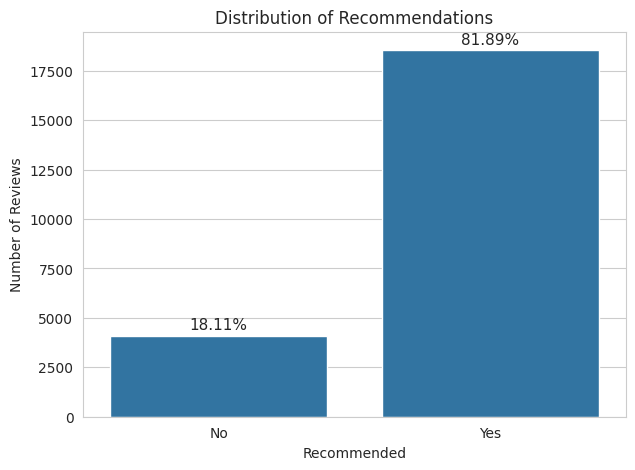

In [8]:
import matplotlib.pyplot as plt

# Count the number of reviews for each recommendation
recommendation_counts = df["recommended_ind"].value_counts().sort_index()

# Calculate the percentage for each recommendation
recommendation_percentages = (recommendation_counts / recommendation_counts.sum()) * 100

# Create the chart
plt.figure(figsize=(7, 5))

ax = sns.barplot(x=["No", "Yes"], y=recommendation_counts.values)

plt.title('Distribution of Recommendations')
plt.xlabel('Recommended')
plt.ylabel('Number of Reviews')

# Adding percentage labels above each bar
for i, percentage in enumerate(recommendation_percentages):
    ax.text(
        i,
        recommendation_counts.iloc[i] + 300,
        f"{percentage:.2f}%",
        ha="center",
        fontsize=11
    )

plt.show()

In [9]:
recommendation_percent = df["recommended_ind"].value_counts(normalize=True) * 100

recommendation_percent.round(2)

,proportion
recommended_ind,
1,81.89
0,18.11


### Business Insight

### Business Insight: Recommendation Behavior

Approximately 81.89% of customers recommended the products, while 18.11% did not.

This indicates that the dataset contains substantially more positive recommendations than negative recommendations.

The recommendation variable will be used as the target variable for the machine learning model.

Because the target variable is imbalanced, accuracy alone will not be sufficient to evaluate the model. Therefore precision, recall, F1-score, and the confusion matrix will also be used for model evaluation

From a business perspective, the approximately 18% of non-recommended reviews are particularly valuable because they can help identify customer dissatisfaction and potential product issues.

## Analysis 3 - Customer Age Analysis

Understanding the age distribution of customers can help businesses understand their primary customer segments.

First the overall age distribution will be examined and then will compare recommendation behavior across different age groups.

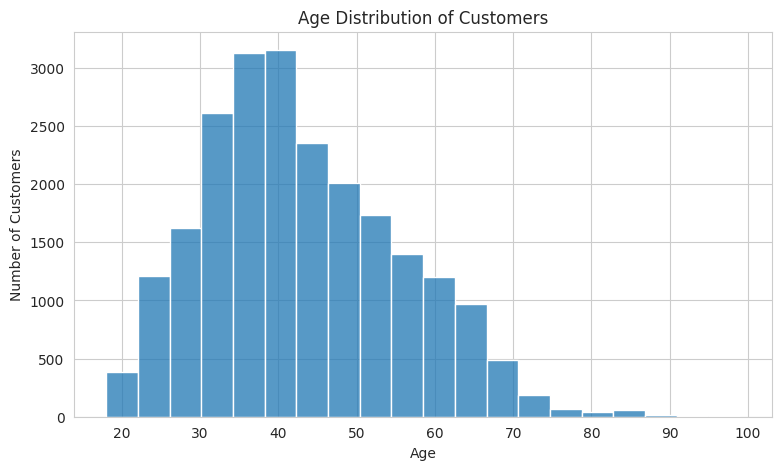

In [10]:
plt.figure(figsize=(9, 5))

sns.histplot(data=df, x='age', bins=20)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

In [11]:
# Customer Age Statistics

# Calculate the average customer age
average_age = df["age"].mean()

# Calculate the median customer age
median_age = df["age"].median()

# Find the youngest customer
youngest_age = df["age"].min()

# Find the oldest customer
oldest_age = df["age"].max()

# Display the results
print("Average Customer Age:", round(average_age, 2))
print("Median Customer Age:", median_age)
print("Youngest Customer Age:", youngest_age)
print("Oldest Customer Age:", oldest_age)

Average Customer Age: 43.28
Median Customer Age: 41.0
Youngest Customer Age: 18
Oldest Customer Age: 99


In [12]:
# Create Customer Age Groups

# Define the age ranges
age_bins = [0, 24, 34, 44, 54, 64, 100]

# Define names for the age groups
age_labels = [
    "Under 25",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

# Create a new column containing the age group
df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

# Display the first few rows
df[["age", "age_group"]].head()

,age,age_group
0,33,25-34
1,34,25-34
2,60,55-64
3,50,45-54
4,47,45-54


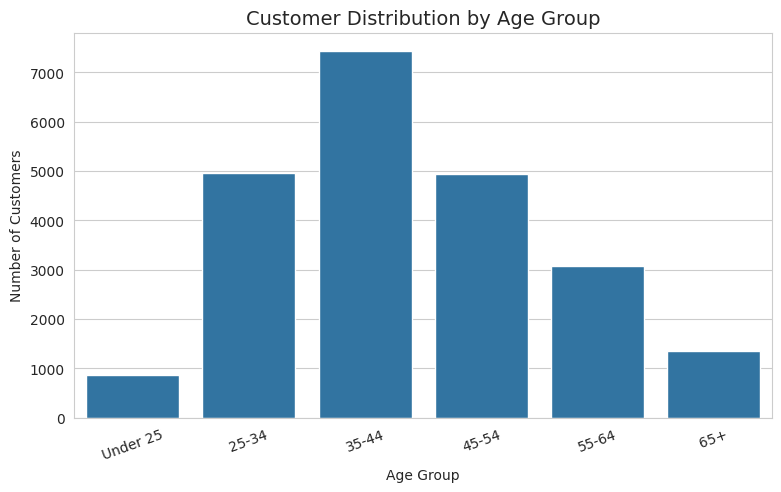

In [13]:
# Age Group Distribution

# Count customers in each age group
age_group_counts = df["age_group"].value_counts().sort_index()

# Create the chart
plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Customer Distribution by Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Rotate labels slightly for readability
plt.xticks(rotation=20)

plt.show()

### Business Insight: Customer Age Distribution

The average customer age is approximately 43 years, while the median age is 41 years.

The largest customer segment is the 35 - 44 age group. Customers between 25 and 54 represent the majority of the reviews in the dataset.

The dataset includes customers ranging from 18 to 99 years old, providing a broad range of customer demographics for analysis.

From a business perspective, the strong representation of customers between 25 and 54 suggests that this age range may be an important customer segment for the products represented in the dataset.

In [14]:
# Recommendation Rate by Age Group

# Calculating the average recommendation value for each group
# Since recommendation rate is either 0 or 1
# the average will be recommendation rate

recommendation_by_age = (df.groupby('age_group')['recommended_ind'].mean() * 100)

recommendation_by_age.round(2)

,recommended_ind
age_group,
Under 25,86.51
25-34,79.40
35-44,81.31
45-54,81.80
55-64,84.57
65+,85.41


### Business Insight: Recommendation Rate by Age

Recommendation rates vary across age groups.

Customers under 25 have the highest recommendation rate at approximately 86.51%, while customers between 25 and 34 have the lowest recommendation rate at approximately 79.40%.

The difference between the highest and lowest groups is about 7 percentage points.

Although these differences are useful for identifying potential customer segments, they should not automatically be interpreted as statistically significant. Some age groups contain fewer reviews than others.

Further analysis could be performed in the future to determine whether age has a statistically meaningful relationship with recommendation behavior.

## Analysis 4 - Rating vs Recommendation

Customer ratings and recommendation behavior are closely related business indicators.

In this analysis, recommendation rates across different rating levels will be compared

This will help to determine whether customers who give higher ratings are more likely to recommend a product.

In [15]:
# Recommendation Rate by Rating

recommendation_by_rating = (df.groupby('rating')['recommended_ind'].mean() * 100)

recommendation_by_rating.round(2)

,recommended_ind
rating,
1,1.83
2,6.07
3,41.45
4,96.66
5,99.82


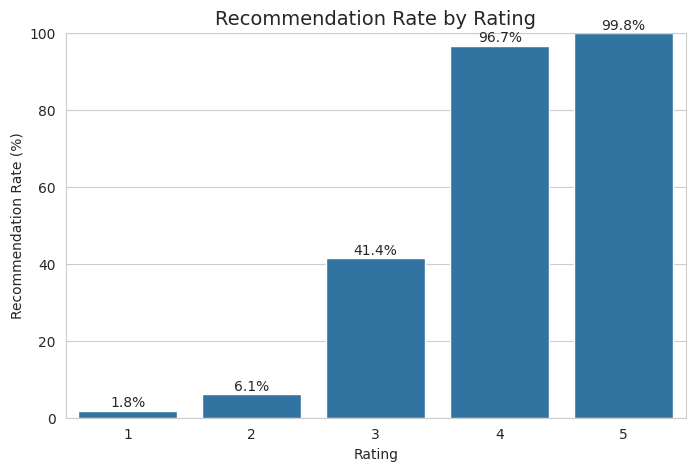

In [16]:
# Visualize recommendation_by_rating

plt.figure(figsize=(8,5))

ax= sns.barplot(x=recommendation_by_rating.index, y=recommendation_by_rating.values)

plt.title('Recommendation Rate by Rating', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Recommendation Rate (%)')

# Set y-axis from 0 to 100
plt.ylim(0, 100)

# Add percentage labels above each bar
for i, value in enumerate(recommendation_by_rating.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

# Display the chart
plt.show()

### Business Insight: Rating and Recommendation

There is a very strong relationship between customer rating and recommendation behavior.

Only 1.83% of customers who gave a 1-star rating recommended the product, while 99.82% of customers who gave a 5-star rating recommended it.

The recommendation rate increases substantially as the rating increases:

- 1-star: 1.83%
- 2-star: 6.07%
- 3-star: 41.45%
- 4-star: 96.66%
- 5-star: 99.82%

The largest change occurs between 3 and 4 stars, where the recommendation rate increases from approximately 41% to 97%.

This suggests that customer rating is a very strong indicator of recommendation behavior.

## Analysis 5 - Department Analysis

### Department Performance Analysis

Different clothing departments may have different levels of customer satisfaction.

In this section, different departments will be compared on the basis of following:

- Number of reviews
- Average rating
- Recommendation rate

This can help businesses identify strong-performing departments and areas that may require improvement.

In [17]:
# Number of reviews per department

review_per_dept =  df["department_name"].value_counts()

review_per_dept

,count
department_name,
Tops,10048
Dresses,6145
Bottoms,3662
Intimate,1653
Jackets,1002
Trend,118
Unknown,13


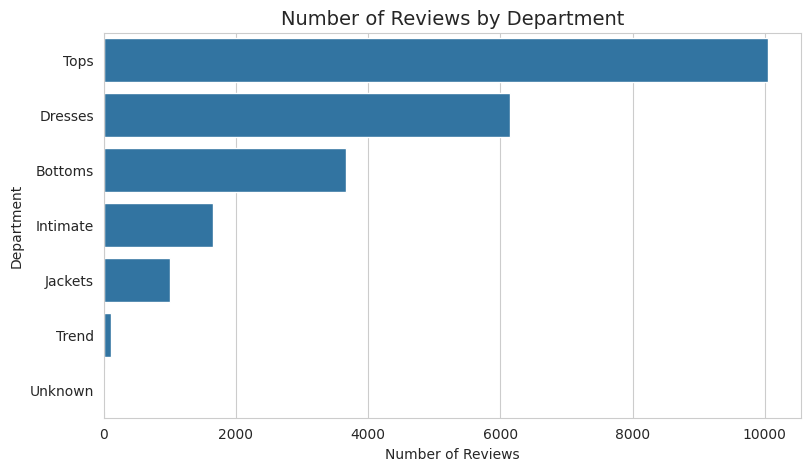

In [18]:
# Visualize Reviews by Department


plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=review_per_dept.values,
    y=review_per_dept.index
)

plt.title("Number of Reviews by Department", fontsize=14)
plt.xlabel("Number of Reviews")
plt.ylabel("Department")
plt.show()

In [19]:
# Average Rating in each Department

avg_rating_per_dept = df.groupby('department_name')['rating'].mean().sort_values(ascending=False)

avg_rating_per_dept.round(2)

,rating
department_name,
Unknown,5.00
Bottoms,4.28
Intimate,4.27
Jackets,4.25
Tops,4.16
Dresses,4.14
Trend,3.84


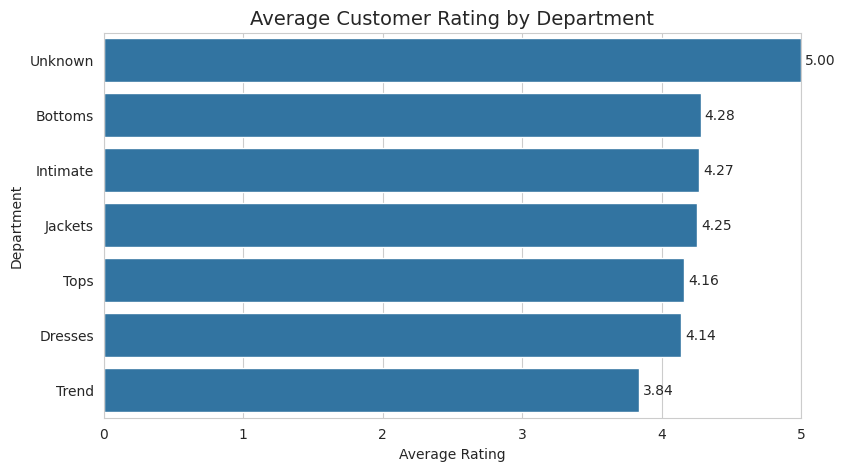

In [20]:
# Visualize Average Rating by Department

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=avg_rating_per_dept.values,
    y=avg_rating_per_dept.index
)

# Add title
plt.title("Average Customer Rating by Department", fontsize=14)

# Add axis labels
plt.xlabel("Average Rating")
plt.ylabel("Department")
plt.xlim(0, 5)

# Add rating values
for i, value in enumerate(avg_rating_per_dept.values):
    ax.text(
        value + 0.03,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.show()

In [21]:
# Recommendation Rate by Department

recommendation_by_dept = (df.groupby('department_name')['recommended_ind'].mean() * 100)

recommendation_by_dept.round(2)

,recommended_ind
department_name,
Bottoms,84.95
Dresses,80.52
Intimate,84.63
Jackets,83.33
Tops,81.07
Trend,74.58
Unknown,100.00


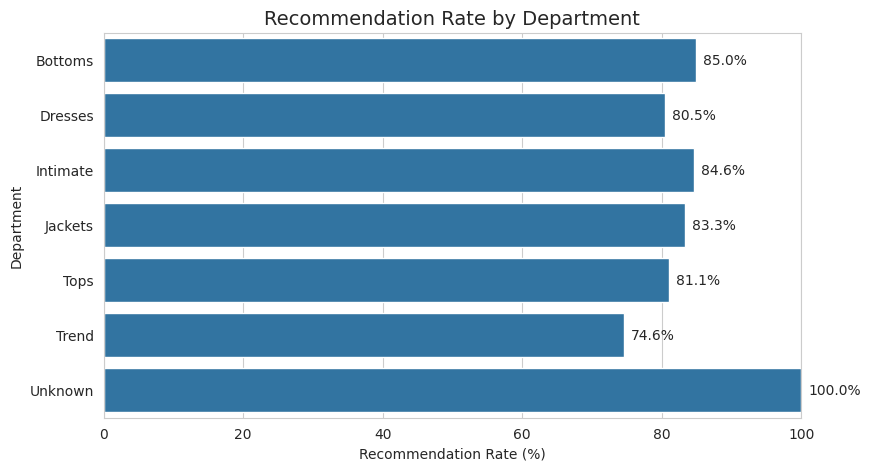

In [22]:
# Visualize Recommendation Rate by Department

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=recommendation_by_dept.values,
    y=recommendation_by_dept.index
)

# Add title
plt.title(
    "Recommendation Rate by Department",
    fontsize=14
)

# Add axis labels
plt.xlabel("Recommendation Rate (%)")
plt.ylabel("Department")
plt.xlim(0, 100)

# Add percentage values
for i, value in enumerate(recommendation_by_dept.values):
    ax.text(
        value + 1,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.show()

## Business Insights: Department Performance

The analysis shows that Tops and Dresses account for the largest number of customer reviews in the dataset. This means conclusions about these departments are supported by relatively large numbers of observations.

Bottoms has the highest average rating among the major departments at approximately 4.28, followed closely by Intimate at 4.27 and Jackets at 4.25.

Trend has the lowest average rating at approximately 3.84 and the lowest recommendation rate at approximately 74.6%. However, Trend contains substantially fewer reviews than the larger departments, so this result should be treated as a potential signal rather than a definitive conclusion.

Bottoms has the highest recommendation rate among the major departments at approximately 85.0%.

The Unknown category shows a 100% recommendation rate and a 5.00 average rating, but it contains very few observations. Therefore, this result should not be interpreted as evidence that Unknown is the best-performing department.

Overall, sample size should be considered when comparing department performance. Departments with very few reviews can produce extreme averages or percentages that may not represent broader customer behavior.

### Department Performance Summary

In [23]:
# Combining review_per_dept, recommendation_per_dept and avg_rating_per_dept in one table

department_summary = pd.DataFrame ({
    'Number of Reviews': review_per_dept,
    'Average Rating': avg_rating_per_dept,
    'Recommendation Rate (%)': recommendation_by_dept
})

# Rounding off the number in columns
department_summary['Average Rating'] = department_summary['Average Rating'].round(2)
department_summary['Recommendation Rate (%)'] = department_summary['Recommendation Rate (%)'].round(2)

# Sort departments by number of reviews
department_summary = department_summary.sort_values(by='Number of Reviews', ascending=False)

# Display department_summary table
department_summary

,Number of Reviews,Average Rating,Recommendation Rate (%)
department_name,,,
Tops,10048,4.16,81.07
Dresses,6145,4.14,80.52
Bottoms,3662,4.28,84.95
Intimate,1653,4.27,84.63
Jackets,1002,4.25,83.33
Trend,118,3.84,74.58
Unknown,13,5.00,100.00


## Analysis 5 — Clothing Class Analysis

Departments provide a broad view of the product catalog, while clothing classes provide more detailed information about individual product categories.

In this section, we will analyze:

- Number of reviews by clothing class
- Average rating by clothing class
- Recommendation rate by clothing class

This can help identify specific product categories that may require further investigation.

### Number of Reviews by Clothing Class

In [24]:
# Number of Reviews by Clothing Class
class_review_count = df["class_name"].value_counts()

class_review_count.head(15)

,count
class_name,
Dresses,6145
Knits,4626
Blouses,2983
Sweaters,1380
Pants,1350
Jeans,1104
Fine gauge,1059
Skirts,903
Jackets,683


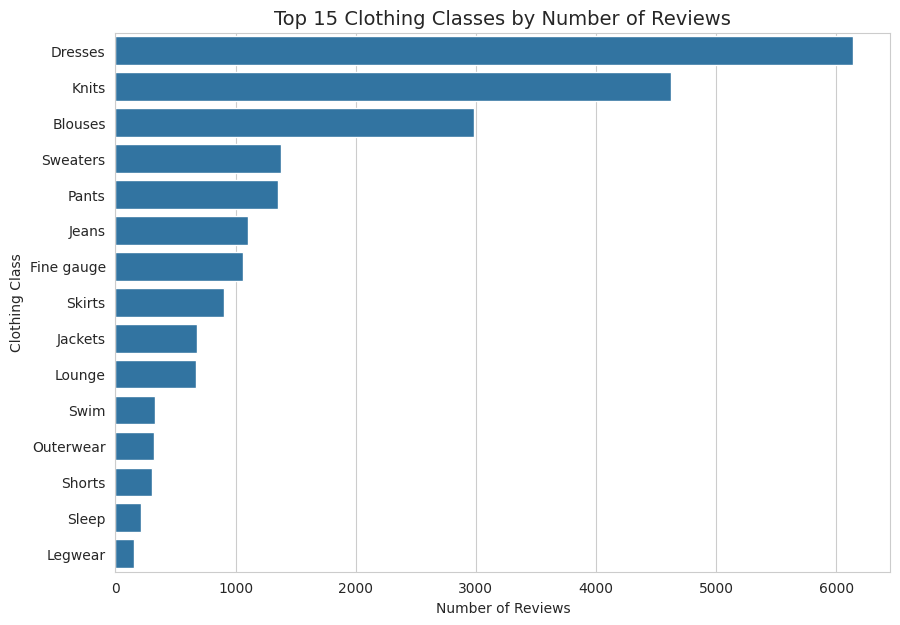

In [25]:
# Visualize Top Clothing Classes

# Select the 15 most reviewed clothing classes
top_classes = class_review_count.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(x=top_classes.values, y=top_classes.index)

plt.title("Top 15 Clothing Classes by Number of Reviews", fontsize=14)
plt.xlabel("Number of Reviews")
plt.ylabel("Clothing Class")
plt.show()

### Average Rating by Clothing Class

In [26]:
# Average Rating by Clothing Class

# Calculate the average rating for each clothing class
avg_rating_per_class = (df.groupby("class_name")["rating"].mean().sort_values(ascending=False))

# Round the results
avg_rating_per_class = avg_rating_per_class.round(2)

# Display the top 15 classes
avg_rating_per_class.head(15)

,rating
class_name,
Unknown,5.00
Layering,4.35
Jeans,4.35
Lounge,4.30
Sleep,4.29
Jackets,4.29
Intimates,4.28
Pants,4.26
Shorts,4.25


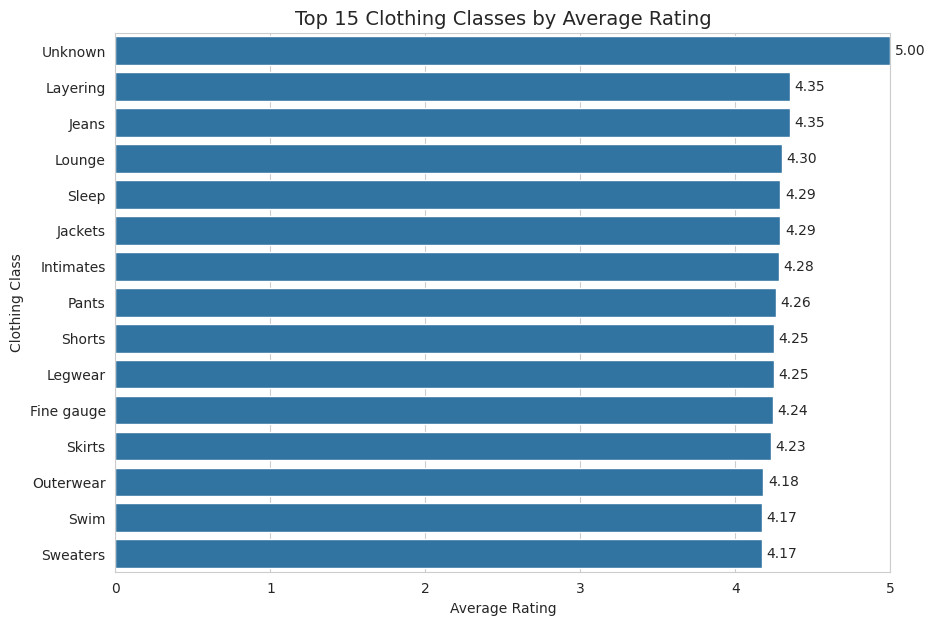

In [27]:
# Visualize Average Rating by Clothing Class

# Select the 15 classes with the highest average ratings
top_rated_classes = avg_rating_per_class.head(15)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=top_rated_classes.values,
    y=top_rated_classes.index
)


plt.title("Top 15 Clothing Classes by Average Rating", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("Clothing Class")

# Set rating scale
plt.xlim(0, 5)

# Add rating values
for i, value in enumerate(top_rated_classes.values):
    ax.text(
        value + 0.03,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.show()

### Filter Classes with Enough Reviews

It can't be immediately assumeed that the top-rated class is actually the "best" product category.

Because a class with 20 reviews and 5.00 average rating isn't as convincing as:

2,000 reviews and 4.70 average rating

So we're going to introduce a minimum review threshold.

Let's only consider clothing classes with at least 100 reviews.

In [28]:
# Filter Classes with At Least 100 Reviews

# Count reviews for every clothing class
class_counts = df["class_name"].value_counts()

# Keep only classes with at least 100 reviews
classes_with_enough_reviews = class_counts[class_counts >= 100].index

# Create a filtered dataset
df_class_filtered = df[df["class_name"].isin(classes_with_enough_reviews)
]

# Display the number of classes remaining
print("Number of classes with at least 100 reviews:", len(classes_with_enough_reviews))

Number of classes with at least 100 reviews: 18


In [29]:
# Average Rating for Well-Represented Classes

# Calculate average rating using only classes
# with at least 100 reviews
filtered_class_rating = (df_class_filtered.groupby("class_name")["rating"].mean().sort_values(ascending=False))

# Round the values
filtered_class_rating = filtered_class_rating.round(2)

filtered_class_rating

,rating
class_name,
Layering,4.35
Jeans,4.35
Lounge,4.30
Sleep,4.29
Jackets,4.29
Intimates,4.28
Pants,4.26
Shorts,4.25
Legwear,4.25


In [30]:
# Recommendation Rate by Clothing Class

filtered_class_recommendation = (df_class_filtered.groupby("class_name")["recommended_ind"].mean()* 100)

# Sort from highest to lowest
filtered_class_recommendation = (
    filtered_class_recommendation
    .sort_values(ascending=False)
    .round(2)
)

# Display the results
filtered_class_recommendation

,recommended_ind
class_name,
Jeans,87.95
Layering,87.88
Lounge,85.80
Intimates,85.71
Sleep,85.51
Legwear,85.44
Jackets,84.33
Skirts,84.16
Shorts,83.88


In [31]:
# Create Clothing Class Performance Summary

# Count reviews for each class
class_review_counts = (df_class_filtered["class_name"].value_counts())

# Create a summary table
class_summary = pd.DataFrame({
    "Number of Reviews": class_review_counts,
    "Average Rating": filtered_class_rating,
    "Recommendation Rate (%)": filtered_class_recommendation
})

# Sort by recommendation rate
class_summary = class_summary.sort_values(
    by="Recommendation Rate (%)",
    ascending=False
)

# Display the summary
class_summary

,Number of Reviews,Average Rating,Recommendation Rate (%)
class_name,,,
Jeans,1104,4.35,87.95
Layering,132,4.35,87.88
Lounge,669,4.30,85.80
Intimates,147,4.28,85.71
Sleep,214,4.29,85.51
Legwear,158,4.25,85.44
Jackets,683,4.29,84.33
Skirts,903,4.23,84.16
Shorts,304,4.25,83.88


### Business Insight: Clothing Class Performance

The clothing class analysis provides a more detailed view of customer satisfaction.

Jeans is one of the strongest-performing categories, with an average rating of 4.35 and a recommendation rate of approximately 87.95%. Lounge also performs strongly, with an average rating of 4.30 and an 85.80% recommendation rate.

Trend appears to be a potential customer friction point. It has the lowest average rating (3.84) and the lowest recommendation rate (74.58%) among the categories included in this analysis. However, Trend has only 118 reviews, so the result should be investigated further rather than treated as a definitive conclusion.

Knits and Dresses have the largest number of reviews, with 4,626 and 6,145 reviews respectively. Although their recommendation rates are not the lowest, their large review volumes make these categories particularly important for business analysis.

Overall, the analysis shows why both customer satisfaction metrics and sample size should be considered when identifying potential product issues.

## Analysis 6 — Positive Feedback

The `positive_feedback_count` column represents the number of other customers who found a review helpful.

Reviews with high positive feedback may contain information that is particularly useful to other shoppers.

In this section, we will:

- Examine the distribution of positive feedback
- Identify highly helpful reviews
- Compare positive feedback with ratings
- Identify reviews that may contain valuable customer insights

In [33]:
df['positive_feedback_count'].describe()

,positive_feedback_count
count,22641.000000
mean,2.630582
std,5.786164
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,122.000000


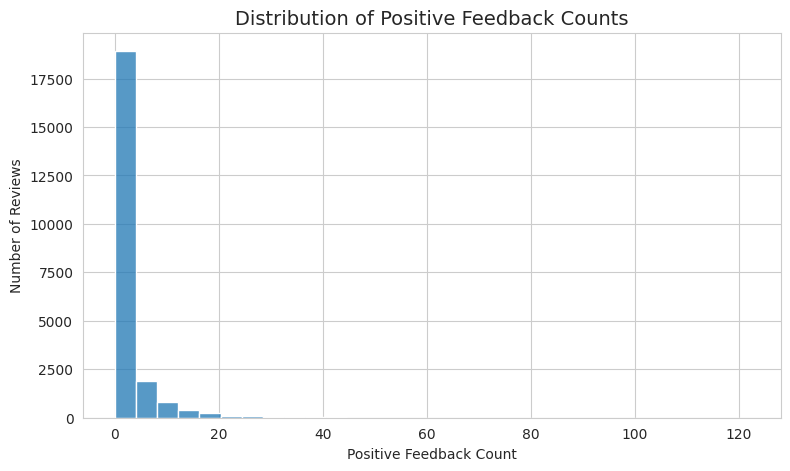

In [34]:
# Distribution of Positive Feedback

# Create a histogram showing positive feedback counts
plt.figure(figsize=(9, 5))

sns.histplot(data=df, x="positive_feedback_count", bins=30)

plt.title("Distribution of Positive Feedback Counts", fontsize=14)
plt.xlabel("Positive Feedback Count")
plt.ylabel("Number of Reviews")

plt.show()

In [36]:
#  Top 10 Most Helpful Reviews

top_10_positive_review = df.sort_values(by='positive_feedback_count', ascending=False)

# Display the 10 most helpful reviews
top_10_positive_review[
    [
        "rating",
        "recommended_ind",
        "positive_feedback_count",
        "title",
        "review_text"
    ]
].head(10)

,rating,recommended_ind,positive_feedback_count,title,review_text
6971,3,1,122,Beware if you're fuller in the chest,I loved the lace detailing all over this dress...
1248,5,1,117,No Title,I've been on the hunt for the perfect dress to...
7493,1,0,108,Quality does not merit cost,"I generally don't write bad reviews, but there..."
18411,5,1,99,A navy trench-yes!,I am a big fan of trench coats and i love that...
12737,5,1,98,"Super flattering, beautiful dress",This is my favorite dress i've bought in the p...
15727,4,1,95,At least it's not a swing top! tts?,I loved the idea of the placement print around...
2052,5,1,94,Another tiny success,Tiny are experts at making busy bohemian shirt...
16607,4,1,93,Stunning but has fit issues,"This top is beautiful, the lace is sturdy and ..."
9094,5,1,89,Knock out!,I am a huge fan of absolutely everything tanvi...
8384,4,1,87,Fun spring colors but tricky on certain body t...,In the store i was immediately drawn to the bl...


### Business Insight: Helpful Customer Reviews

The most helpful reviews include both positive and negative customer experiences.

Several highly helpful reviews discuss specific product characteristics such as fit, quality, body shape, and value for money. For example, some reviews with high positive feedback mention fit issues even when the overall rating is positive.

This suggests that helpfulness is not determined only by whether a customer recommends a product.

Detailed feedback about potential problems may be particularly valuable to other shoppers. Therefore, the NLP stage of ShopSense AI will focus not only on overall sentiment but also on identifying important words, phrases, and potential customer friction points.

## Analysis 7 — Review Length

Customer reviews vary considerably in length.

Review length can provide useful information about customer engagement and may also affect NLP model performance.

In this section, we will:

- Calculate the number of words in each review
- Examine the distribution of review lengths
- Compare review length with customer ratings
- Identify unusually long reviews

In [38]:
# Calculate word count in the column review

df['review_word_count'] = df['review_text'].str.split().str.len()

# Displaying first 5 reviews with the word count
df[['review_text','review_word_count']].head(5)

,review_text,review_word_count
0,Absolutely wonderful - silky and sexy and comf...,8
1,Love this dress! it's sooo pretty. i happene...,62
2,I had such high hopes for this dress and reall...,98
3,"I love, love, love this jumpsuit. it's fun, fl...",22
4,This shirt is very flattering to all due to th...,36


In [39]:
# Review Length Statistics

# Calculate summary statistics for review length
df["review_word_count"].describe()

,review_word_count
count,22641.000000
mean,60.196679
std,28.534612
min,2.000000
25%,36.000000
50%,59.000000
75%,88.000000
max,115.000000


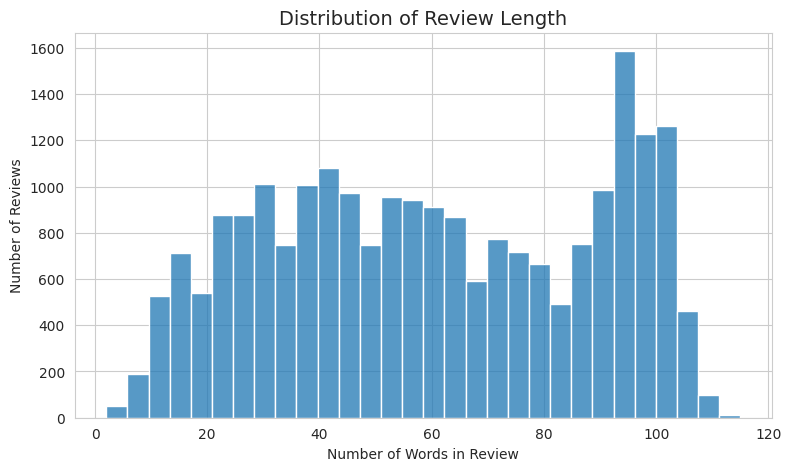

In [40]:
# Review Length Distribution

# Create a histogram of review word counts
plt.figure(figsize=(9, 5))

sns.histplot(data=df, x="review_word_count", bins=30)

plt.title("Distribution of Review Length", fontsize=14)
plt.xlabel("Number of Words in Review")
plt.ylabel("Number of Reviews")

plt.show()

In [41]:
# Average Review Length by Rating

# Calculate the average review length for each rating
review_length_by_rating = ( df.groupby("rating")["review_word_count"].mean().round(2))

review_length_by_rating

,review_word_count
rating,
1,58.63
2,62.06
3,64.22
4,63.32
5,57.94


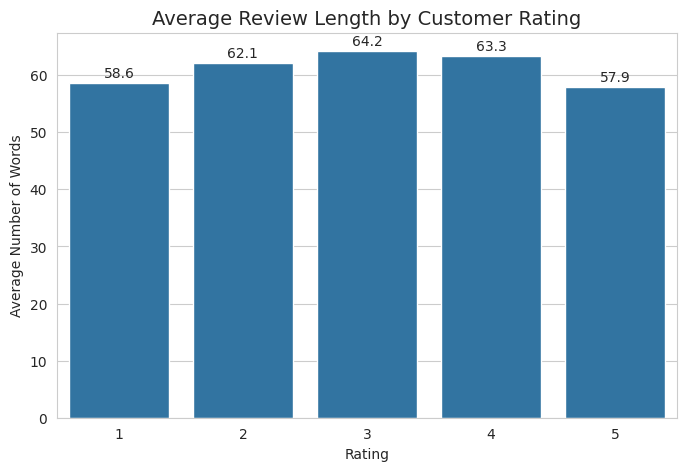

In [42]:
# Visualize Review Length by Rating

plt.figure(figsize=(8, 5))

ax = sns.barplot(x=review_length_by_rating.index, y=review_length_by_rating.values)

plt.title("Average Review Length by Customer Rating", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Average Number of Words")

# Add values above the bars
for i, value in enumerate(review_length_by_rating.values):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}",
        ha="center"
    )

plt.show()

### Business Insight: Review Length

The dataset contains 22,641 customer reviews with an average length of approximately 60 words. The median review length is 59 words, while reviews range from 2 to 115 words.

Review length varies somewhat across rating levels. Three-star reviews are the longest on average at approximately 64.22 words, while five-star reviews are the shortest at approximately 57.94 words.

The difference suggests that customers may provide more detailed feedback when their experience is mixed or moderately positive. However, this analysis only shows an association and does not establish that review length causes a particular rating.

Review length will be retained as a potential feature for future analysis and machine learning experiments.

# EDA Summary

In this notebook, we explored several important aspects of the Women's E-Commerce Clothing Reviews dataset.

### Key Areas Analyzed

- Customer rating distribution
- Recommendation behavior
- Customer age distribution
- Recommendation rate by age group
- Relationship between rating and recommendation
- Department performance
- Clothing class performance
- Positive feedback and helpful reviews
- Review length

### Key Business Findings

The dataset is strongly positive overall, with approximately 81.89% of reviews recommending the product.

Customer ratings have a strong relationship with recommendation behavior. Customers giving 4 or 5 stars are substantially more likely to recommend products.

The largest customer age segment is 35–44.

At the department level, Bottoms has one of the strongest recommendation rates among major departments, while Trend shows lower satisfaction metrics but has a relatively small number of reviews.

At the clothing-class level, Jeans performs strongly, while Trend appears to be a potential customer friction point.

Highly helpful reviews include both positive and negative experiences, indicating that specific product feedback may be valuable regardless of overall sentiment.

Review length will be further investigated as a potential feature for the NLP and machine learning stages.

### Next Step

The next notebook will focus on Natural Language Processing (NLP), where we will transform raw customer review text into a format that machine learning algorithms can understand.